# Gazette: static print figure

Generates a single high-resolution image suitable for newspaper publication.
The figure mirrors **Fig 1** from the interactive piece — drive time to the
nearest pharmacy *before* and *after* the Hardwick Walgreens closed in 2024 —
but cropped to the area immediately around Hardwick and rendered as a static
PNG/PDF (no Leaflet, no interactivity).

Output: `../docs/gazette_hardwick.png` and `../docs/gazette_hardwick.pdf`.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import geopandas as gpd
import matplotlib.colors as mcolors
import matplotlib.patheffects as pe
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import numpy as np
import pandas as pd
import shapely
from scipy.spatial import cKDTree
from shapely.ops import unary_union

DATA_DIR = Path("../data")
OUTPUT_DIR = Path("../docs")
OUTPUT_DIR.mkdir(exist_ok=True)

# Hardwick Walgreens (closed 2024) — same approximate coordinates as 31-render.
HARDWICK_WALGREENS = {"name": "Walgreens (closed 2024)", "lat": 44.5044, "lon": -72.3660}

# Bounding box for the Hardwick-area crop. Wide enough to include the nearest
# active pharmacies (Morrisville to the west, Lyndonville/St. J. to the east)
# and the surrounding towns whose residents felt the closure most.
BBOX = {"w": -72.78, "e": -71.92, "s": 44.30, "n": 44.80}

GRID_RES = 600        # pixels per axis on the cropped grid (~85 m/pixel)
CONTOUR_THRESHOLD = 20.0  # minutes — definition of a pharmacy desert

## Load data

Same inputs as `31-render.ipynb`: address-level drive-time matrix, the cached
drive times to the closed Hardwick Walgreens, and the active-pharmacy list.

In [2]:
addresses = pd.read_csv(DATA_DIR / "addresses_with_population_weights.csv")
dur_raw = np.load(DATA_DIR / "osrm_address_pharmacy_duration_sec.npy")
t_walgreens_sec = np.load(DATA_DIR / "hardwick_walgreens_drive_times_sec.npy")
with (DATA_DIR / "pharmacies_active.json").open() as f:
    pharm_records = json.load(f)
boundary_gdf = gpd.read_file(DATA_DIR / "counties_five_vt.geojson")

w_raw = addresses["population_weight"].to_numpy(dtype=np.float64)
d_sec = np.where(np.isfinite(dur_raw), dur_raw.astype(np.float64), np.inf)
t_after_min = d_sec.min(axis=1) / 60.0
t_before_min = np.minimum(t_after_min, t_walgreens_sec / 60.0)

keep = np.isfinite(t_after_min) & np.isfinite(w_raw) & (w_raw >= 0)
addresses = addresses.loc[keep].reset_index(drop=True)
w = w_raw[keep]
t_after_min = t_after_min[keep]
t_before_min = t_before_min[keep]
addr_lon = addresses["lon"].to_numpy(dtype=np.float64)
addr_lat = addresses["lat"].to_numpy(dtype=np.float64)

region = unary_union(boundary_gdf.geometry)

# Headline statistics for the caption — restricted to addresses inside the crop.
in_box = (
    (addr_lon >= BBOX["w"]) & (addr_lon <= BBOX["e"])
    & (addr_lat >= BBOX["s"]) & (addr_lat <= BBOX["n"])
)
pop_box = w[in_box].sum()
pop_box_over20_before = w[in_box & (t_before_min > 20)].sum()
pop_box_over20_after = w[in_box & (t_after_min > 20)].sum()

print(f"Addresses in crop: {in_box.sum():,}  |  weighted population: {pop_box:,.0f}")
print(f"% > 20 min — before: {pop_box_over20_before/pop_box*100:5.1f}%"
      f"  |  after: {pop_box_over20_after/pop_box*100:5.1f}%")

Addresses in crop: 41,062  |  weighted population: 70,583
% > 20 min — before:  15.9%  |  after:  23.3%


## Interpolate drive times to a high-res grid over the crop

Same Delaunay-based scheme as `31-render.ipynb`, but the grid covers only the
Hardwick-area bounding box at higher resolution (~85 m/pixel) so the printed
image is sharp.

In [3]:
lon_g = np.linspace(BBOX["w"], BBOX["e"], GRID_RES)
lat_g = np.linspace(BBOX["s"], BBOX["n"], GRID_RES)
LON_MESH, LAT_MESH = np.meshgrid(lon_g, lat_g)

# Restrict the triangulation to addresses near the crop (with a generous
# buffer) — keeps interpolation fast and avoids long thin triangles.
buffer_deg = 0.3
near = (
    (addr_lon >= BBOX["w"] - buffer_deg) & (addr_lon <= BBOX["e"] + buffer_deg)
    & (addr_lat >= BBOX["s"] - buffer_deg) & (addr_lat <= BBOX["n"] + buffer_deg)
)
TRI = mtri.Triangulation(addr_lon[near], addr_lat[near])

# Mask grid points outside the 5-county study region (the analysis isn't valid
# beyond the address sample, e.g. across the NH/Canada borders).
_gpts = shapely.points(LON_MESH.ravel(), LAT_MESH.ravel())
INSIDE = shapely.within(_gpts, region).reshape(LON_MESH.shape)

# Nearest-neighbour fallback for any grid cells outside the convex hull.
_kdtree = cKDTree(np.column_stack([addr_lon[near], addr_lat[near]]))
_NN_IDX = _kdtree.query(np.column_stack([LON_MESH.ravel(), LAT_MESH.ravel()]))[1]


def interp_to_grid(values_full: np.ndarray) -> np.ndarray:
    values = values_full[near]
    lin = mtri.LinearTriInterpolator(TRI, values)
    gz = lin(LON_MESH, LAT_MESH).filled(np.nan)
    nn = values[_NN_IDX].reshape(LON_MESH.shape)
    gz = np.where(np.isnan(gz), nn, gz)
    return np.where(INSIDE, gz, np.nan)


grid_before = interp_to_grid(t_before_min)
grid_after = interp_to_grid(t_after_min)
print(f"Grid: {grid_before.shape}  |  inside-region cells: {INSIDE.sum():,}")

Grid: (600, 600)  |  inside-region cells: 355,289


## Map furniture: pharmacies and town labels in the crop

Only show points that actually fall inside the cropped bounding box. The town
list comes from `vt_village_centers.csv`; we hand-pick the towns that anchor
the reader's mental map of the area.

In [4]:
pharm_in_box = [
    p for p in pharm_records
    if BBOX["w"] <= p["lon"] <= BBOX["e"] and BBOX["s"] <= p["lat"] <= BBOX["n"]
]
print(f"Active pharmacies in crop: {len(pharm_in_box)}")

# Towns to label on the map. Coordinates from data/vt_village_centers.csv.
# Anchor offsets keep labels off their dot; tuned for the chosen bbox/figsize.
TOWN_LABELS = [
    {"name": "Hardwick",    "lat": 44.5043, "lon": -72.3660, "dx":  4, "dy":  6, "weight": "bold"},
    {"name": "Morrisville", "lat": 44.5641, "lon": -72.5984, "dx":  5, "dy":  5},
    {"name": "Greensboro",  "lat": 44.5760, "lon": -72.2957, "dx":  5, "dy":  4},
    {"name": "Craftsbury",  "lat": 44.6361, "lon": -72.3733, "dx":  5, "dy":  4},
    {"name": "Wolcott",     "lat": 44.5466, "lon": -72.4579, "dx":  5, "dy": -10},
    {"name": "Walden",      "lat": 44.4498, "lon": -72.2233, "dx":  5, "dy":  4},
    {"name": "Cabot",       "lat": 44.4029, "lon": -72.3104, "dx":  5, "dy":  4},
    {"name": "Woodbury",    "lat": 44.4414, "lon": -72.4151, "dx": -6, "dy":  4, "ha": "right"},
    {"name": "Marshfield",  "lat": 44.3513, "lon": -72.3535, "dx":  5, "dy":  4},
    {"name": "Stannard",    "lat": 44.5423, "lon": -72.2149, "dx":  5, "dy":  4},
    {"name": "Barton",      "lat": 44.7485, "lon": -72.1807, "dx":  5, "dy":  4},
    {"name": "Glover",      "lat": 44.7071, "lon": -72.1870, "dx":  5, "dy":  4},
    {"name": "Eden",        "lat": 44.7074, "lon": -72.5454, "dx":  5, "dy":  4},
    {"name": "Lyndonville",     "lat": 44.5331, "lon": -72.0034, "dx": -6, "dy":  4, "ha": "right"},
    {"name": "Danville",        "lat": 44.4108, "lon": -72.1418, "dx": -6, "dy":  4, "ha": "right"},
    {"name": "St. Johnsbury",   "lat": 44.4259, "lon": -72.0184, "dx": -6, "dy":  4, "ha": "right"},
]

Active pharmacies in crop: 15


## Render the figure

Two side-by-side panels share the same axes and colormap. The before panel
flags the closed Walgreens with an "X" marker; the after panel shows only
the active pharmacies.

Wrote ../docs/gazette_hardwick.png  (1678 KB)
Wrote ../docs/gazette_hardwick.pdf  (1837 KB)


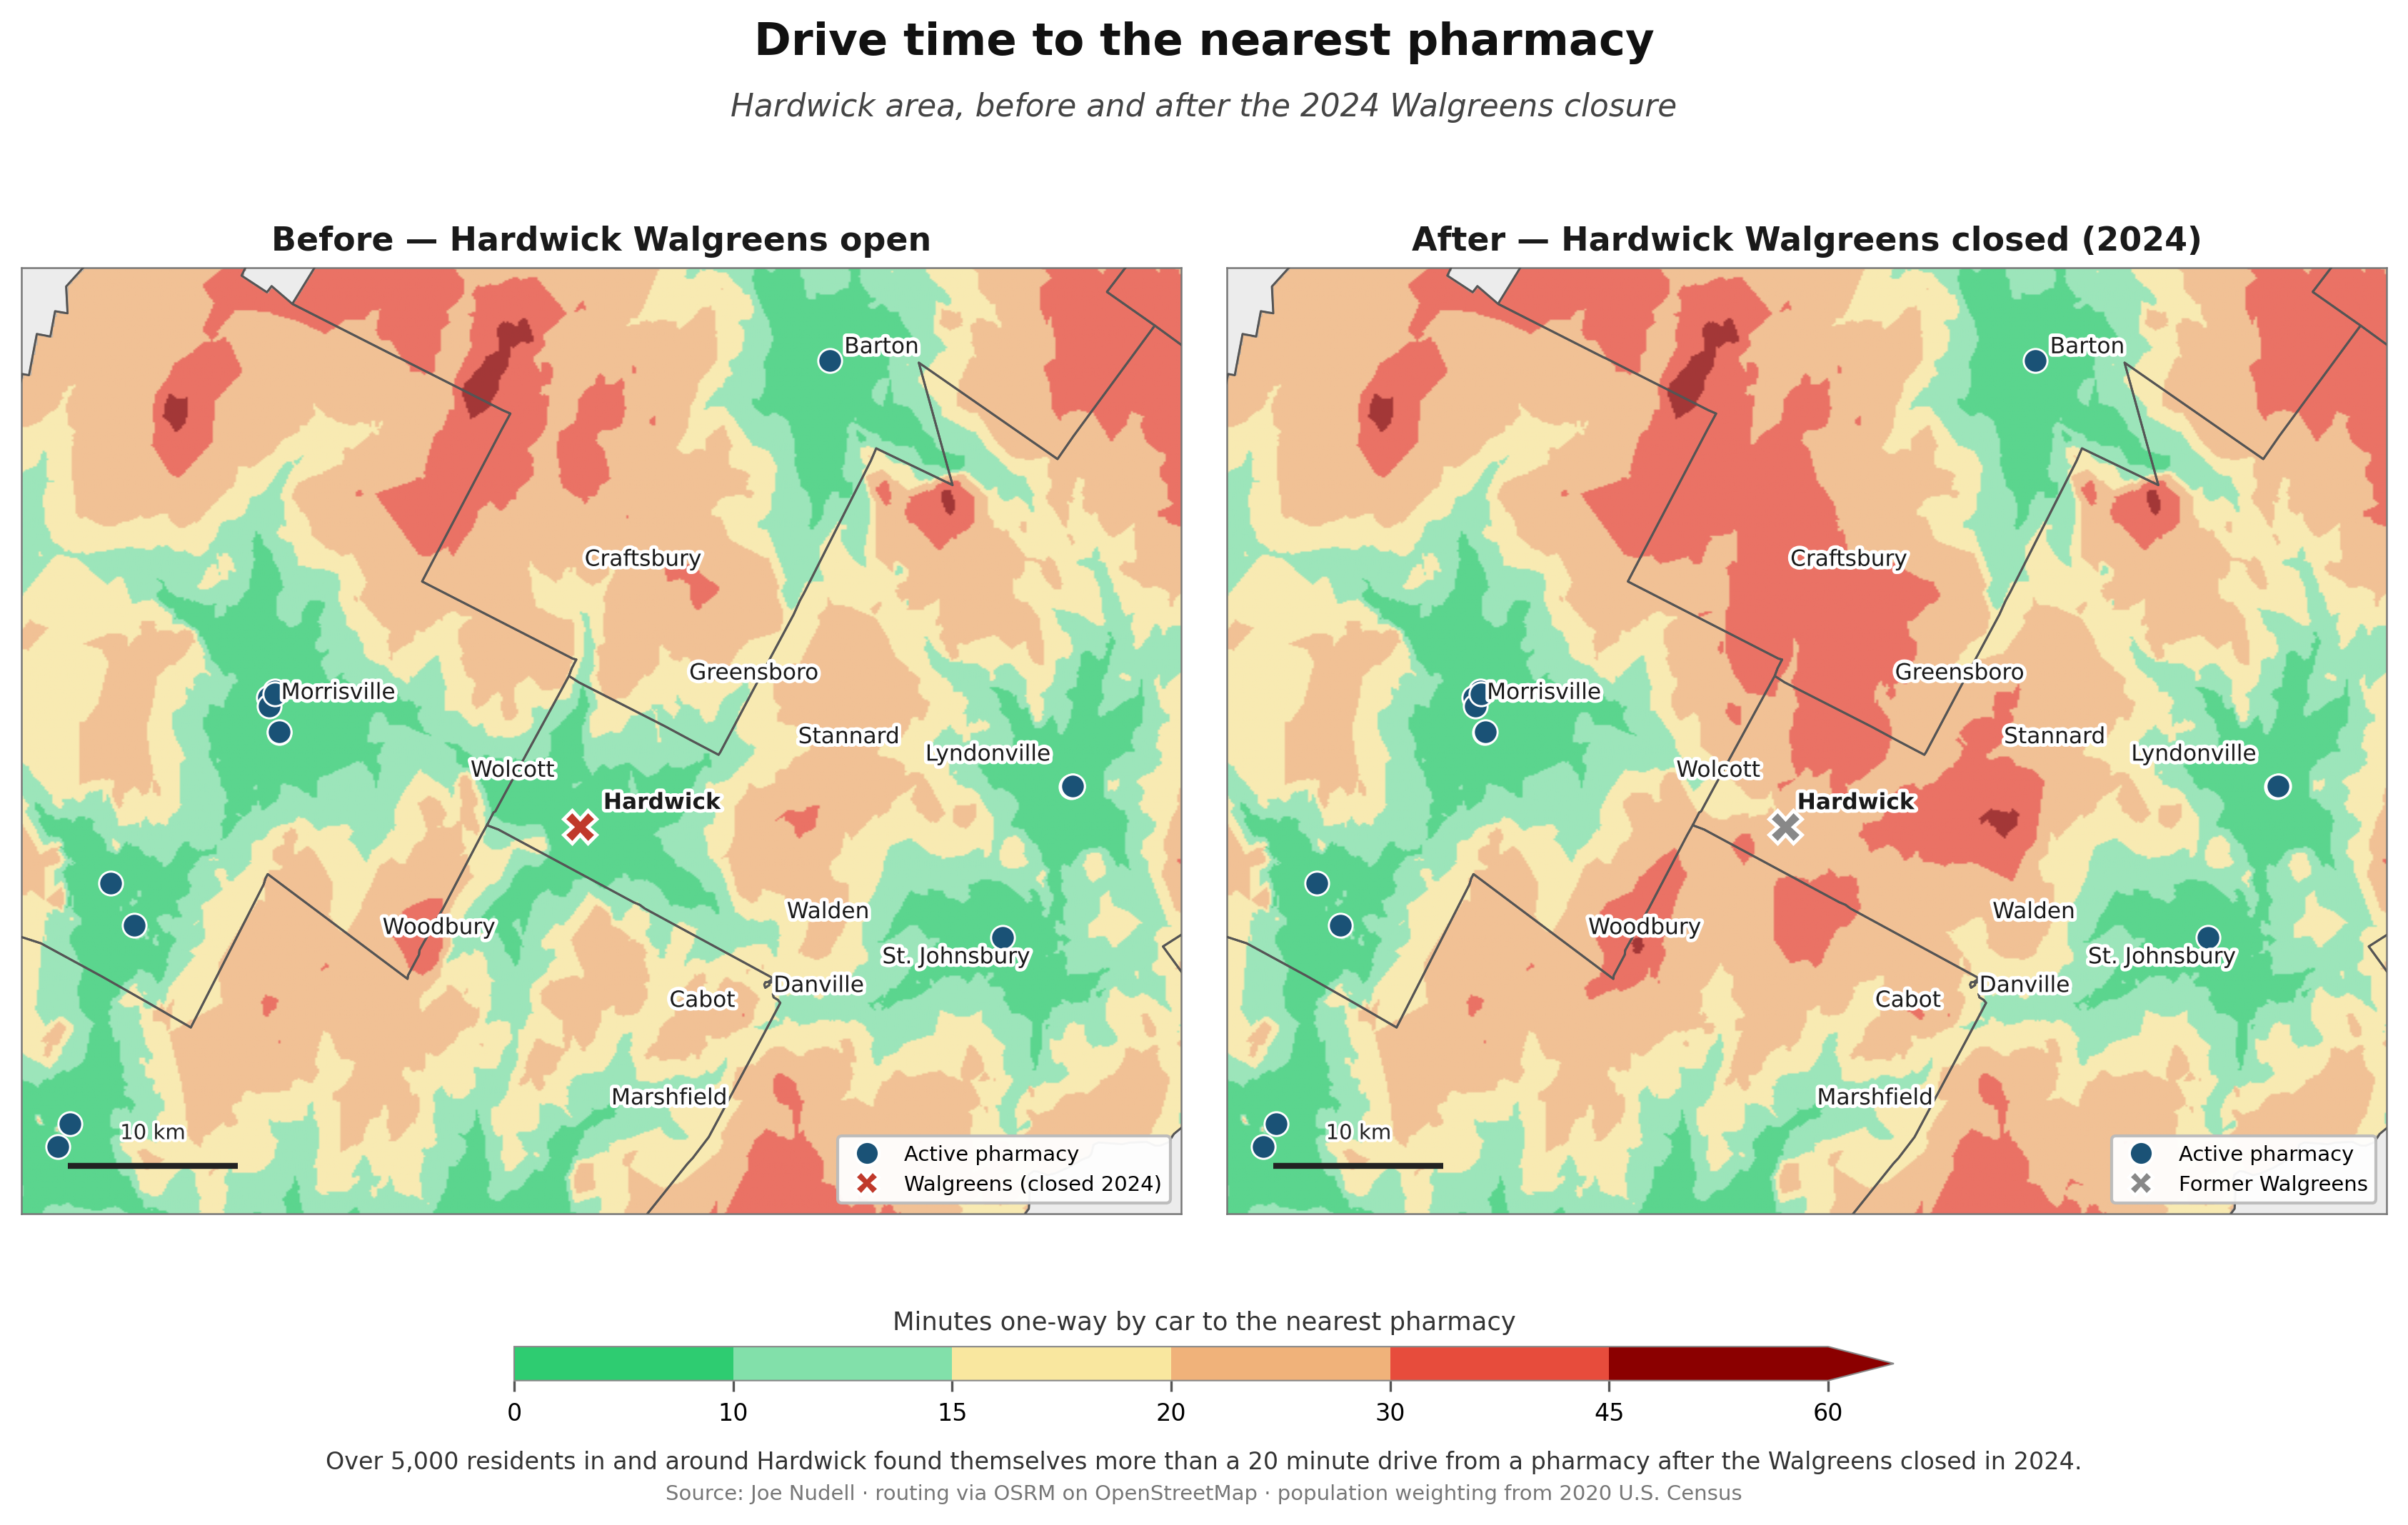

In [ ]:
import math

# Banded colormap — six categories, sharp boundaries that survive newsprint.
CMAP_COLORS = ["#2ecc71", "#82e0aa", "#f9e79f", "#f0b27a", "#e74c3c", "#8b0000"]
CMAP_BREAKS = [0, 10, 15, 20, 30, 45, 60]
DRIVE_CMAP = mcolors.ListedColormap(CMAP_COLORS)
DRIVE_CMAP.set_over(CMAP_COLORS[-1])
DRIVE_CMAP.set_bad((0, 0, 0, 0))   # NaN → transparent
DRIVE_NORM = mcolors.BoundaryNorm(CMAP_BREAKS, DRIVE_CMAP.N)


def draw_panel(ax, grid: np.ndarray, *, title: str, walgreens: str) -> None:
    """walgreens: 'open' (red X + 'Hardwick' callout) or 'closed' (gray X, no callout)."""
    ax.set_facecolor("#ececec")
    boundary_gdf.plot(
        ax=ax, facecolor="#f7f7f4", edgecolor="#9a9a9a", linewidth=0.6, zorder=1,
    )
    ax.imshow(
        grid,
        extent=(BBOX["w"], BBOX["e"], BBOX["s"], BBOX["n"]),
        origin="lower", cmap=DRIVE_CMAP, norm=DRIVE_NORM,
        alpha=0.78, interpolation="bilinear", zorder=2,
    )
    boundary_gdf.boundary.plot(ax=ax, edgecolor="#555", linewidth=0.7, zorder=3)

    for p in pharm_in_box:
        ax.plot(
            p["lon"], p["lat"],
            marker="o", markersize=8,
            markerfacecolor="#1a5276", markeredgecolor="white", markeredgewidth=0.7,
            linestyle="none", zorder=5,
        )

    halo = [pe.withStroke(linewidth=2.4, foreground="white")]

    # Town dots and labels — but skip the "Hardwick" label on the Before panel,
    # because the Walgreens X marker (which stands at the same point) carries
    # the label there instead.
    for t in TOWN_LABELS:
        if walgreens == "open" and t["name"] == "Hardwick":
            continue
        ax.plot(
            t["lon"], t["lat"],
            marker="o", markersize=0, markerfacecolor="#222",
            markeredgecolor="white", markeredgewidth=0.4,
            linestyle="none", zorder=4,
        )
        ax.annotate(
            t["name"],
            xy=(t["lon"], t["lat"]),
            xytext=(t.get("dx", 4), t.get("dy", 4)), textcoords="offset points",
            ha=t.get("ha", "left"),
            fontsize=7.5,
            fontweight=t.get("weight", "normal"),
            color="#1a1a1a",
            path_effects=halo,
            zorder=8,
        )

    if walgreens == "open":
        ax.plot(
            HARDWICK_WALGREENS["lon"], HARDWICK_WALGREENS["lat"],
            marker="X", markersize=11,
            markerfacecolor="#c0392b", markeredgecolor="white", markeredgewidth=1.2,
            linestyle="none", zorder=6,
        )
        ax.annotate(
            "Hardwick",
            xy=(HARDWICK_WALGREENS["lon"], HARDWICK_WALGREENS["lat"]),
            xytext=(8, 6), textcoords="offset points",
            ha="left", fontsize=7.5, fontweight="bold", color="#1a1a1a",
            path_effects=halo, zorder=8,
        )
    elif walgreens == "closed":
        ax.plot(
            HARDWICK_WALGREENS["lon"], HARDWICK_WALGREENS["lat"],
            marker="X", markersize=11,
            markerfacecolor="#888888", markeredgecolor="white", markeredgewidth=1.2,
            linestyle="none", zorder=6,
        )

    ax.set_xlim(BBOX["w"], BBOX["e"])
    ax.set_ylim(BBOX["s"], BBOX["n"])
    ax.set_aspect(1.0 / np.cos(np.deg2rad(0.5 * (BBOX["s"] + BBOX["n"]))))
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_color("#777"); spine.set_linewidth(0.6)
    ax.set_title(title, fontsize=11, fontweight="bold", color="#1a1a1a", pad=6)


def add_scale_bar(ax, km: float = 10) -> None:
    """Lower-left scale bar, length given in kilometres."""
    lat_mid = 0.5 * (BBOX["s"] + BBOX["n"])
    deg_per_km_lon = 1.0 / (111.32 * np.cos(np.deg2rad(lat_mid)))
    length_deg = km * deg_per_km_lon
    x0 = BBOX["w"] + 0.04 * (BBOX["e"] - BBOX["w"])
    y0 = BBOX["s"] + 0.05 * (BBOX["n"] - BBOX["s"])
    ax.plot([x0, x0 + length_deg], [y0, y0], color="#222", lw=2, zorder=9,
            solid_capstyle="butt")
    ax.text(x0 + length_deg / 2, y0 + 0.012, f"{km} km",
            ha="center", va="bottom", fontsize=7, color="#222",
            path_effects=[pe.withStroke(linewidth=2, foreground="white")],
            zorder=10)


fig, (ax_b, ax_a) = plt.subplots(
    1, 2, figsize=(11.5, 7.2), dpi=300, sharex=True, sharey=True,
    gridspec_kw={"wspace": 0.04},
)
fig.subplots_adjust(left=0.02, right=0.98, top=0.84, bottom=0.16)

draw_panel(ax_b, grid_before, title="Before — Hardwick Walgreens open",          walgreens="open")
draw_panel(ax_a, grid_after,  title="After — Hardwick Walgreens closed (2024)",  walgreens="closed")
add_scale_bar(ax_b, km=10)
add_scale_bar(ax_a, km=10)

# Pharmacy legend (lower-right of each panel).
ax_b.plot([], [], marker="o", markersize=8, markerfacecolor="#1a5276",
          markeredgecolor="white", linestyle="none", label="Active pharmacy")
ax_b.plot([], [], marker="X", markersize=8, markerfacecolor="#c0392b",
          markeredgecolor="white", linestyle="none", label="Walgreens (closed 2024)")
ax_a.plot([], [], marker="o", markersize=8, markerfacecolor="#1a5276",
          markeredgecolor="white", linestyle="none", label="Active pharmacy")
ax_a.plot([], [], marker="X", markersize=8, markerfacecolor="#888888",
          markeredgecolor="white", linestyle="none", label="Former Walgreens")
ax_b.legend(loc="lower right", fontsize=7, frameon=True, facecolor="white",
            edgecolor="#bbb", framealpha=0.95)
ax_a.legend(loc="lower right", fontsize=7, frameon=True, facecolor="white",
            edgecolor="#bbb", framealpha=0.95)

# Top-of-figure title and subtitle.
fig.text(0.5, 0.945, "Drive time to the nearest pharmacy",
         ha="center", fontsize=15, fontweight="bold", color="#111")
fig.text(0.5, 0.905, "Hardwick area, before and after the 2024 Walgreens closure",
         ha="center", fontsize=10.5, color="#444", style="italic")

# Shared horizontal colorbar.
cax = fig.add_axes([0.22, 0.085, 0.56, 0.022])
cbar = fig.colorbar(
    plt.cm.ScalarMappable(norm=DRIVE_NORM, cmap=DRIVE_CMAP),
    cax=cax, orientation="horizontal", extend="max",
    ticks=CMAP_BREAKS,
)
cbar.ax.tick_params(labelsize=8, color="#555")
cbar.outline.set_edgecolor("#888")
cbar.outline.set_linewidth(0.5)
fig.text(0.5, 0.118, "Minutes one-way by car to the nearest pharmacy",
         ha="center", fontsize=8.5, color="#333")

# Source / credit line at the very bottom.
delta_pop = pop_box_over20_after - pop_box_over20_before
fig.text(
    0.5, 0.028,
    f"Over {math.floor(delta_pop / 1000) * 1000:,.0f} residents in and around Hardwick found themselves "
    "more than a 20 minute drive from a pharmacy after the Walgreens closed in 2024.",
    ha="center", fontsize=8, color="#333",
)
fig.text(
    0.5, 0.008,
    "Source: Joe Nudell. Drive times estimated with OSRM and OpenStreetMap. "
    "Population estimates from 2020 U.S. Census.",
    ha="center", fontsize=7, color="#777",
)

PNG_PATH = OUTPUT_DIR / "gazette_hardwick.png"
PDF_PATH = OUTPUT_DIR / "gazette_hardwick.pdf"
fig.savefig(PNG_PATH, dpi=300, facecolor="white")
fig.savefig(PDF_PATH, facecolor="white")
print(f"Wrote {PNG_PATH}  ({PNG_PATH.stat().st_size // 1024} KB)")
print(f"Wrote {PDF_PATH}  ({PDF_PATH.stat().st_size // 1024} KB)")
plt.show()